<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day01_practice2_%EA%B8%B0%EC%B4%88%EC%88%98%ED%95%99_autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False

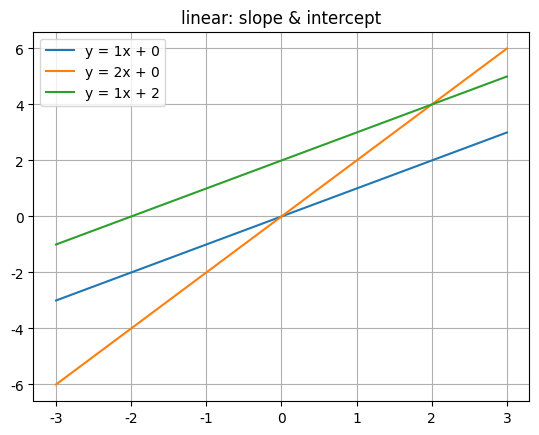

기울기 a가 커지면 가파라지고, b는 위아래로 평행이


In [2]:
# 셀 1. 일차 함수 - 기울기와 y 절편
# y = ax + b (a: 기울기, b: y 절편)
# y = wx + b (w: 가중치, b: 편향) - 선형회귀

x = torch.linspace(-3,3,100) # -3부터 3까지 100개 점
for a, b in [(1,0), (2,0), (1,2)]:
  y=a*x+b
  plt.plot(x,y,label=f"y = {a}x + {b}") # x와 y변수의 데이터를 사용하여 선 그래프 그리기

plt.legend(); plt.grid(True); plt.title("linear: slope & intercept")
plt.savefig("plot1_linear.png")
plt.show()
print("기울기 a가 커지면 가파라지고, b는 위아래로 평행이")

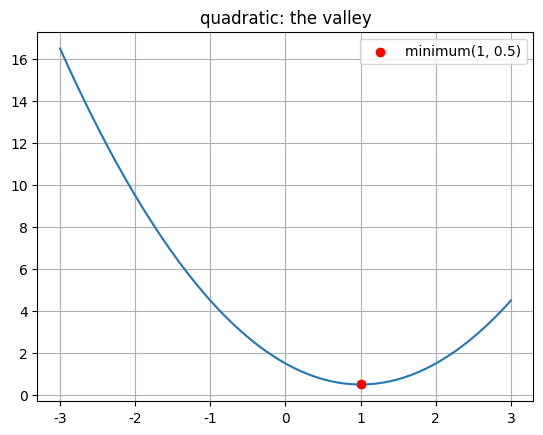

손실 함수의 골짜기 모양 - 빨간 점(최소값)이 학습의 목적지


In [3]:
# 셀 2. 이차 함수와 최솟값
# 딥러닝의 손실 함수는 대개 '아래로 볼록한 골짜기' 모양
# 학습 = 이 골짜기의 가장 낮은 점(최솟값)을 찾아 내려간느 것
# 최솟값에서는 기울기가 0입니다 ← 미분 필요

y = (x-1) ** 2 + 0.5 # 꼭짓점이 (1, 0.5)인 이차 함수

plt.plot(x,y)
plt.scatter([1],[0.5],color="red",zorder=5, label="minimum(1, 0.5)")
plt.legend(); plt.grid(True); plt.title("quadratic: the valley")
plt.savefig("plot2_quadratic.png")
plt.show()
print("손실 함수의 골짜기 모양 - 빨간 점(최소값)이 학습의 목적지")

In [4]:
# 셀 3. 미분 = 순간 변화율, 기울기
# f(x) = x² 의 미분은 f'(x) = 2x (공식)

def f(x):
  return x ** 2

x0 = torch.tensor(3.0) # 스칼라 값
h= 1e-5 # 아주 작은 0.00001(10의 -5승)
수치미분 = (f(x0 + h) - f(x0)) / h # (변화한 y) / (변화한 x)
print(f"f(x)=x² 의 x=3 에서의 기울기")
print(f" 미분 공식(2x) : {2 * x0.item():.4f}") #.item()은 PyTorch 텐서인 x0의 값을 Python 숫자로 변환
print(f" 수치 근사 : {수치미분.item():.4f}")

# 둘이 거의 같음 → 미분 = 순간 변화율

f(x)=x² 의 x=3 에서의 기울기
 미분 공식(2x) : 6.0000
 수치 근사 : 6.0081


In [5]:
# 셀 4. autograd - PyTorch가 미분을 대신한다

x0 = torch.tensor(3.0, requires_grad=True) #이 텐서에 대한 미분을 추적해라

y = x0 ** 2 # y = x²(PyTorch가 계산 과정을 기록 중)
y.backward() # 역방향으로 미분 실행
# y텐서로부터 역방향 전파(backward propagation)를 시작하여 x0 텐서까지의 모든 연산에 대한 기울기를 계산
# 즉, y를 x0에 대해 미분한 값(dy/dx0)이 계산, 이 기울기 값은 x0.grad에 저장

# backward() 호출을 통해 계산된 x0의 기울기(x0.grad)를 출력

print("autograd가 구한 dy/dx:", x0.grad.item())
# 미분 공식, 수치근사, autograd 세 값이 모두 6

autograd가 구한 dy/dx: 6.0


In [6]:
# 셀 5. 편미분 - 변수가 2개일 때
# f(w, b) = w² + 3b   →  ∂f/∂w = 2w,  ∂f/∂b = 3
w = torch.tensor(2.0, requires_grad=True) # 이 텐서에 대한 미분을 추적해라
b = torch.tensor(1.0, requires_grad=True)

f_val = w ** 2 + 3 * b
f_val.backward()

print("n\편미분 결과")
print("∂f/∂w =",w.grad.item(), "(미분공식 3=3)")
print("∂f/∂w =",b.grad.item(), "(미분공식 3)")

# 신경망의 가중치는 수백만 개 = 변수가 수백만 개인 편미분

n\편미분 결과
∂f/∂w = 4.0 (미분공식 3=3)
∂f/∂w = 3.0 (미분공식 3)


In [7]:
# 셀 6. 경사 하강법 맛보기 - 골짜기를 실제로 내려가 보자

x = torch.tensor(4.0, requires_grad=True) # 아무데서나 출발
lr = 0.1 # 학습률: 한 걸음의 크기
경로 = []

for step in range(30):
  y = (x - 1) ** 2 + 0.5 # y = (x-1)²+ 0.5
  y.backward() # 미분 y' = 2*(x-1) → x.grad = 2*(4-1) = 6

  with torch.no_grad(): # PyTorch의 자동 미분 추적을 비활성화, 단순히 x의 위치 이동 자체는 기록하지 않음
    x -= lr * x.grad # 새로운 x = 4 - (0.1 * 6) = 3.4
                     # 경사 하강법의 목표는 산의 가장 낮은 골짜기(최솟값)를 찾아 내려가는 것. 함수 값이 가장 빠르게 감소하는 방향으로 이동
                     # 기울기 값에 음수(-)를 곱하여 '기울기 반대 방향'으로 이동하는 이유
  x.grad.zero_() # 기울기 초기화(누적 방지) - PyTorch는 backward()가 호출될 때마다 기울기를 누적, 다음 스텝에서 새로운 기울기를 정확히 계산

  경로.append(x.item())

print("\n경사 하강 경로(30걸음):")
print(" 출발 4.0 →", "→".join(f"{v:.2f}" for v in 경로[::6]), f"→{경로[-1]:.4f}") #전체 리스트 :: 에서 6step 건너뛰며 선택. 1,7 선택됨
print(" 최소값의 위치 x=1에 도착")


경사 하강 경로(30걸음):
 출발 4.0 → 3.40→1.63→1.16→1.04→1.01 →1.0037
 최소값의 위치 x=1에 도착


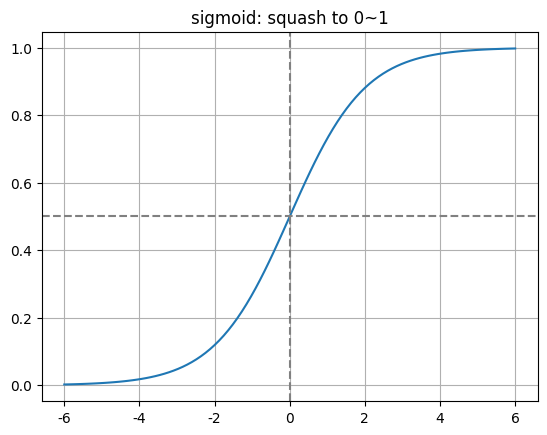

sigmoid(-6): 0.0025 = 0
sigmoid(0): 0.5 = 0.5
sigmoid(+6): 0.9975 = 1


In [8]:
# 셀 7. 시그모이드 함수 - 활성화 함수는 신경망의 각 뉴런에서 비선형성을 부여하고 출력값을 변환하는 역할
# 시그모이드: 어떤 수든 0~1 사이로 눌러 넣는 함수

x = torch.linspace(-6, 6, 100)
sig = torch.sigmoid(x)

plt.plot(x,sig)
plt.axhline(0.5,color='gray',ls="--"); plt.axvline(0, color="gray", ls="--")
plt.grid(True); plt.title("sigmoid: squash to 0~1")
plt.savefig("plot3_sigmoid.png")
plt.show()
print("sigmoid(-6):", round(torch.sigmoid(torch.tensor(-6.0)).item(), 4), "= 0")
print("sigmoid(0):", round(torch.sigmoid(torch.tensor(0.0)).item(), 4), "= 0.5")
print("sigmoid(+6):", round(torch.sigmoid(torch.tensor(+6.0)).item(), 4), "= 1")